In [1]:
import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb
import json
from matplotlib.colors import ListedColormap

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "nemotron_MATH_PartialMTP_Gating"

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

# Shared palette / output dir for all paper figures.
PALETTE   = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, 2)]
COL_PRI   = PALETTE[0]
COL_SEC   = PALETTE[1]
PLOTS_DIR = Path("/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
out_dir   = PLOTS_DIR  # backwards-compatible alias used by later cells


def _emnlp_ax(ax, ygrid=True):
    """Apply the shared EMNLP single-column axis cosmetics."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=2, pad=1.5)
    if ygrid:
        ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
        ax.set_axisbelow(True)

In [3]:
RUN_IDS = {
    "$k=3$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop3.jsonl",
    "$k=7$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop7.jsonl",
    "$k=11$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop11.jsonl",
    "$k=15$": "/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop15.jsonl",
}


# Cross-loop recoverability analysis

For each sample (doc_id) we record `exact_match` under every loop count L ∈ {3, 5, 7, 9}.

A **recoverable** sample is one that is wrong in at least one loop *and* correct in at least one other loop — i.e. the model "could have" gotten it right with a different L.

The output below contains:
- A 2-D heatmap of pairwise corrections: `cell[i, j]` = # samples wrong under `L_i` but right under `L_j`.
- A bar chart of per-loop accuracy.
- A bar chart of "recovery rate": of the mistakes made by `L_i`, what fraction is fixed by *any* other loop.
- A breakdown by the number of loops a sample is correct in (0/1/2/3/4).
- A JSON dump of doc_ids per category, written under `loop_MTP_paper/data/recoverability/`.

In [4]:
# ---------------------------------------------------------------------------
# 1. Load every loop's predictions and join into one tidy dataframe.
#    Each row = (doc_id, label, {L: exact_match}, {L: model_answer}, {L: continuation})
# ---------------------------------------------------------------------------
LOOP_KEYS = list(RUN_IDS.keys())  # ['L=3', 'L=5', 'L=7', 'L=9']

per_loop = {}
for k, path in RUN_IDS.items():
    with open(path) as f:
        rows = [json.loads(line) for line in f]
    per_loop[k] = {r["doc_id"]: r for r in rows}
    print(f"{k}: {len(rows):4d} predictions  ({path})")

# Sanity check: all loops share the same doc_id set.
doc_ids = sorted(set.intersection(*(set(d.keys()) for d in per_loop.values())))
assert all(len(d) == len(doc_ids) for d in per_loop.values()), "doc_id sets differ across loops"
print(f"\nShared doc_ids: {len(doc_ids)}")

# Build a long dataframe.
records = []
for did in doc_ids:
    label = per_loop[LOOP_KEYS[0]][did]["label"]
    rec = {"doc_id": did, "label": label}
    for k in LOOP_KEYS:
        r = per_loop[k][did]
        rec[f"em_{k}"]   = int(r["metrics"]["exact_match"])
        rec[f"ans_{k}"]  = r["model_output"][0]["model_answer"]
        rec[f"toks_{k}"] = r["metrics"]["num_tokens"]
        rec[f"maxtok_{k}"] = bool(r["metrics"]["max_tokens_reached"])
    records.append(rec)

df = pd.DataFrame(records).set_index("doc_id")
em_cols = [f"em_{k}" for k in LOOP_KEYS]
df["n_correct"]   = df[em_cols].sum(axis=1)
df["any_correct"] = df["n_correct"] > 0
df["all_correct"] = df["n_correct"] == len(LOOP_KEYS)

print("\nPer-loop accuracy:")
for k in LOOP_KEYS:
    acc = df[f"em_{k}"].mean()
    print(f"  {k}: {acc*100:6.2f}%   ({int(df[f'em_{k}'].sum())}/{len(df)})")
print(f"\nFraction solved by at least one loop:  {df['any_correct'].mean()*100:6.2f}%")
print(f"Fraction solved by ALL loops:         {df['all_correct'].mean()*100:6.2f}%")
print(f"Fraction never solved by any loop:    {(1 - df['any_correct'].mean())*100:6.2f}%")

df.head()

$k=3$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop3.jsonl)
$k=7$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop7.jsonl)
$k=11$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop11.jsonl)
$k=15$: 1319 predictions  (/raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/thought_anchor/models_responses/tuned/loop15.jsonl)

Shared doc_ids: 1319

Per-loop accuracy:
  $k=3$:  12.81%   (169/1319)
  $k=7$:  18.12%   (239/1319)
  $k=11$:  15.92%   (210/1319)
  $k=15$:  19.03%   (251/1319)

Fraction solved by at least one loop:   34.72%
Fraction solved by ALL loops:           4.02%
Fraction never solved by any loop:     65.28%


,label,em_$k=3$,ans_$k=3$,toks_$k=3$,maxtok_$k=3$,em_$k=7$,ans_$k=7$,toks_$k=7$,maxtok_$k=7$,em_$k=11$,ans_$k=11$,toks_$k=11$,maxtok_$k=11$,em_$k=15$,ans_$k=15$,toks_$k=15$,maxtok_$k=15$,n_correct,any_correct,all_correct
doc_id,,,,,,,,,,,,,,,,,,,,
0,18,0,136,104,False,0,16,512,True,0,96,77,False,1,18,88,False,1,True,False
1,3,1,3,36,False,1,3,31,False,1,3,31,False,1,3,28,False,4,True,True
2,70000,0,115000,119,False,0,195000,91,False,0,195000,89,False,0,115000,93,False,0,False,False
3,540,0,180,32,False,1,540,34,False,0,180,27,False,0,180,36,False,1,True,False
4,20,0,40,57,False,0,51,512,True,0,40,64,False,0,40,58,False,0,False,False


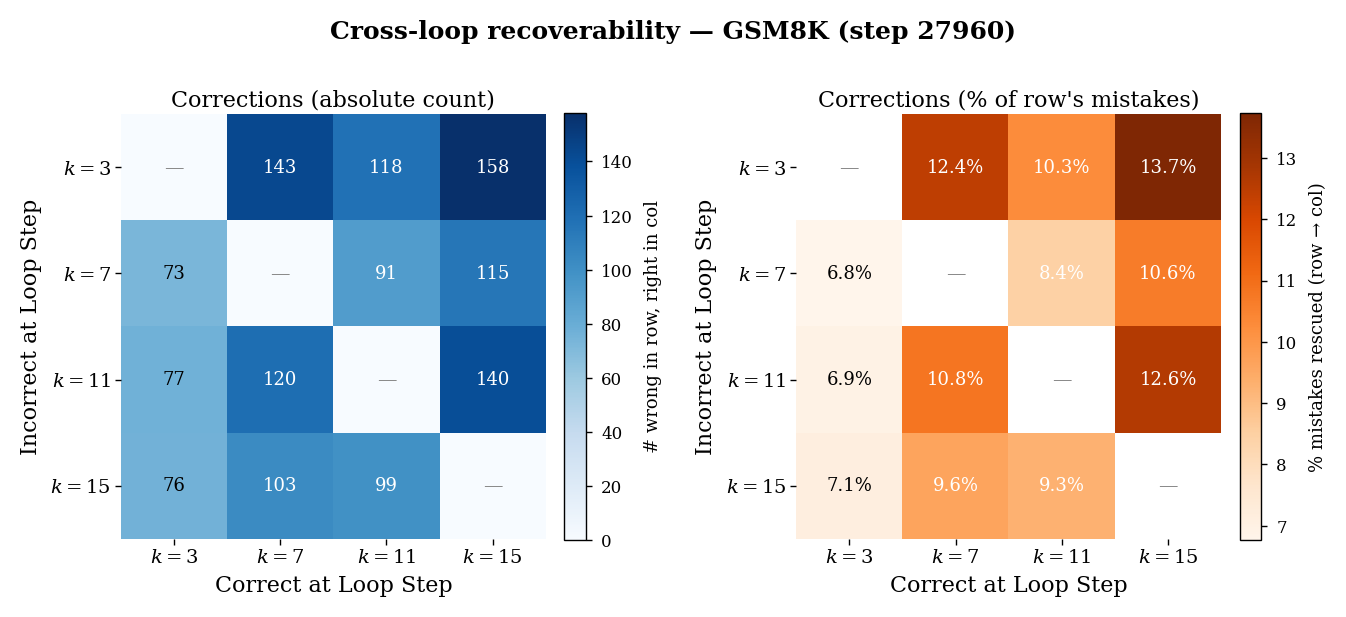


Absolute pairwise correction counts:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$      73      0      91     115
$k=11$     77    120       0     140
$k=15$     76    103      99       0

As % of row-loop's mistakes:
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  12.43   10.26   13.74
$k=7$    6.76    NaN    8.43   10.65
$k=11$   6.94  10.82     NaN   12.62
$k=15$   7.12   9.64    9.27     NaN


In [5]:
# ---------------------------------------------------------------------------
# 2. Pairwise "correction" heatmap.
#    M[i, j] = # samples WRONG under L_i but CORRECT under L_j     (i = row, j = col)
#    Diagonal is set to NaN (a loop cannot rescue itself).
# ---------------------------------------------------------------------------
n = len(LOOP_KEYS)
M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)   # normalized by # wrongs in row i

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())
    for j, kj in enumerate(LOOP_KEYS):
        if i == j:
            continue
        cnt = int((wrong_mask[ki] & right_mask[kj]).sum())
        M_count[i, j] = cnt
        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.8))

def _heat(ax, mat, title, fmt, cmap, cbar_label):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(LOOP_KEYS)
    ax.set_yticks(range(n)); ax.set_yticklabels(LOOP_KEYS)
    ax.set_xlabel("Correct at Loop Step", labelpad=3)
    ax.set_ylabel("Incorrect at Loop Step", labelpad=3)
    ax.set_title(title, pad=3)
    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=7)
            else:
                v = mat[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white" if v > np.nanmax(mat) * 0.55 else "black",
                        fontsize=6.5)
    ax.tick_params(length=2, pad=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)

_heat(axes[0], M_count.astype(float), "Corrections (absolute count)",
      "{:.0f}", "Blues", "# wrong in row, right in col")
_heat(axes[1], M_pct_of_wrong_i,
      "Corrections (% of row's mistakes)",
      "{:.1f}%", "Oranges", "% mistakes rescued (row → col)")

fig.suptitle("Cross-loop recoverability — GSM8K (step 27960)",
             y=1.05, fontsize=9, fontweight="bold")
fig.tight_layout(pad=0.3, w_pad=1.5)

fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAbsolute pairwise correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))
print("\nAs % of row-loop's mistakes:")
print(pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).round(2))

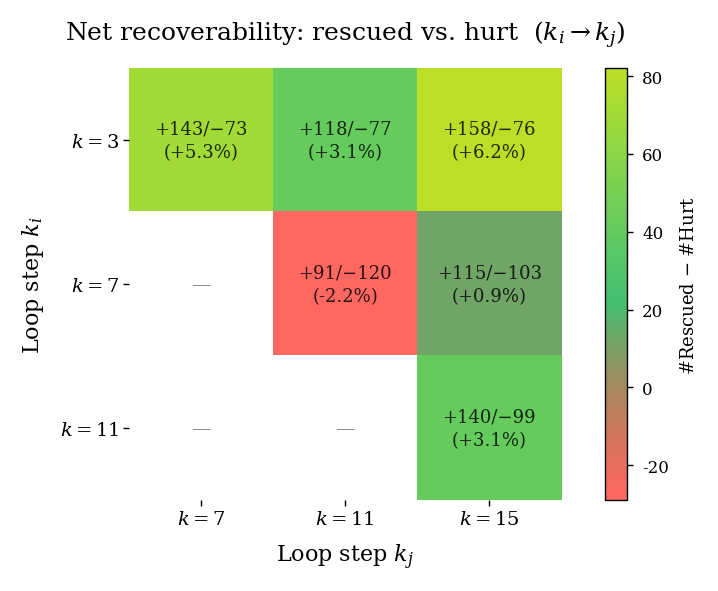


Total samples (denominator for %): 1319

Rescued counts (wrong@row -> right@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$       0      0      91     115
$k=11$      0      0       0     140
$k=15$      0      0       0       0

Hurt counts (right@row -> wrong@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0     73      77      76
$k=7$       0      0     120     103
$k=11$      0      0       0      99
$k=15$      0      0       0       0

Net (rescued - hurt):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   70.0    41.0    82.0
$k=7$     NaN    NaN   -29.0    12.0
$k=11$    NaN    NaN     NaN    41.0
$k=15$    NaN    NaN     NaN     NaN

Rescued % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  10.84    8.95   11.98
$k=7$     NaN    NaN    6.90    8.72
$k=11$    NaN    NaN     NaN   10.61
$k=15$    NaN    NaN     NaN     NaN

Hurt % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   5.53   

In [7]:
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------------------------------------------------------------------------
# 3. Pairwise NET recoverability heatmap (rescued vs hurt).
# ---------------------------------------------------------------------------

n = len(LOOP_KEYS)
N = len(df)

M_rescued = np.zeros((n, n), dtype=int)
M_hurt    = np.zeros((n, n), dtype=int)
M_net     = np.full((n, n), np.nan)

M_rescued_pct = np.full((n, n), np.nan)
M_hurt_pct    = np.full((n, n), np.nan)

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    for j, kj in enumerate(LOOP_KEYS):
        if j <= i:
            continue
        r = int((wrong_mask[ki] & right_mask[kj]).sum())
        h = int((right_mask[ki] & wrong_mask[kj]).sum())
        M_rescued[i, j] = r
        M_hurt[i, j]    = h
        M_net[i, j]     = r - h
        M_rescued_pct[i, j] = r / N * 100.0
        M_hurt_pct[i, j]    = h / N * 100.0


# ---------------------------------------------------------------------------
# Drop the always-empty first column (j=0) and last row (i=n-1).
# ---------------------------------------------------------------------------
net_view = M_net[:-1, 1:]
x_labels = LOOP_KEYS[1:]
y_labels = LOOP_KEYS[:-1]

vmin = float(np.nanmin(net_view))
vmax = float(np.nanmax(net_view))
vmin = min(vmin, -1e-9)
vmax = max(vmax,  1e-9)

# ---------------------------------------------------------------------------
# Linear normalization (NOT TwoSlopeNorm). Zero sits at its true proportional
# position on the bar -> short red section, long green section.
# ---------------------------------------------------------------------------
norm = Normalize(vmin=vmin, vmax=vmax)

# Build the colormap so its red->green transition aligns with 0 in data space.
zero_frac = (0.0 - vmin) / (vmax - vmin)   # fraction of bar below 0
n_total = 256
n_neg = max(1, int(round(zero_frac * n_total)))
n_pos = n_total - n_neg

pos_colors = plt.cm.viridis(np.linspace(0.7, 0.9, 80))
neg_anchor = pos_colors[0]
neg_colors = LinearSegmentedColormap.from_list(
    "neg", ["#ff0d009f", neg_anchor]
)(np.linspace(0, 1, n_neg))
cmap = LinearSegmentedColormap.from_list(
    "viridis_div_red", np.vstack([neg_colors, pos_colors])
)

# ---------------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.0))
im = ax.imshow(net_view, cmap=cmap, norm=norm)

rows, cols = net_view.shape
ax.set_xticks(range(cols)); ax.set_xticklabels(x_labels)
ax.set_yticks(range(rows)); ax.set_yticklabels(y_labels)
ax.set_xlabel(r"Loop step $k_j$", labelpad=5)
ax.set_ylabel(r"Loop step $k_i$", labelpad=5)
ax.set_title("Net recoverability: rescued vs. hurt  ($k_i \\to k_j$)",
             fontsize=9, pad=10)

for i in range(rows):
    for j in range(cols):
        orig_i = i
        orig_j = j + 1
        if orig_j <= orig_i:
            ax.text(j, i, "—", ha="center", va="center",
                    color="gray", fontsize=7)
            continue
        net = M_net[orig_i, orig_j]
        if np.isnan(net):
            continue
        txt_color = "#000000D2"
        net_pct = net / N * 100.0
        ax.text(
            j, i,
            f"+{M_rescued[orig_i, orig_j]}/−{M_hurt[orig_i, orig_j]}\n"
            f"({net_pct:+.1f}%)",
            ha="center", va="center", color=txt_color, fontsize=6.5,
            linespacing=1.4,
        )

ax.tick_params(length=2, pad=1.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------------------------
# Colorbar: evenly spaced ticks every `tick_step` units across the whole bar.
# Zero is naturally included; spacing is uniform in data units.
# ---------------------------------------------------------------------------
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("#Rescued $-$ #Hurt", fontsize=6.5)

tick_step = 20   # change to 10 / 25 to taste
cb.ax.yaxis.set_major_locator(MultipleLocator(tick_step))
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}"))
cb.ax.tick_params(labelsize=6, length=2)
cb.outline.set_linewidth(0.5)

fig.tight_layout()

fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap.pdf",
            bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# Print tables
# ---------------------------------------------------------------------------
idx, col = LOOP_KEYS, LOOP_KEYS
print(f"\nTotal samples (denominator for %): {N}")
print("\nRescued counts (wrong@row -> right@col):")
print(pd.DataFrame(M_rescued, index=idx, columns=col))
print("\nHurt counts (right@row -> wrong@col):")
print(pd.DataFrame(M_hurt, index=idx, columns=col))
print("\nNet (rescued - hurt):")
print(pd.DataFrame(M_net, index=idx, columns=col))
print("\nRescued % (of all samples):")
print(pd.DataFrame(M_rescued_pct, index=idx, columns=col).round(2))
print("\nHurt % (of all samples):")
print(pd.DataFrame(M_hurt_pct, index=idx, columns=col).round(2))

In [93]:
# ---------------------------------------------------------------------------
# 7. Helper to pretty-print a single doc across all loops for manual review.
#    Use: show_doc(123)  or  show_doc(indices["pairwise"]["wrong_in_L=3__right_in_L=7"][0])
# ---------------------------------------------------------------------------
def show_doc(did: int, max_chars: int = 600):
    print(f"=== doc_id={did}    gold label = {per_loop[LOOP_KEYS[0]][did]['label']} ===")
    for k in LOOP_KEYS:
        r = per_loop[k][did]
        em = r["metrics"]["exact_match"]
        ans = r["model_output"][0]["model_answer"]
        cont = r["model_output"][0]["continuation"]
        if len(cont) > max_chars:
            cont = cont[:max_chars] + " …[truncated]"
        marker = "✓" if em == 1.0 else "✗"
        print(f"\n[{k}] {marker}  answer={ans!r}   tokens={r['metrics']['num_tokens']}"
              f"   max_tok_reached={r['metrics']['max_tokens_reached']}")
        print(f"    {cont}")

# Example call — first sample wrong in L=3 but right in L=7.
example = indices["pairwise"].get("wrong_in_L=7__right_in_L=9", [])
if example:
    show_doc(example[0])

In [95]:
n_samples

array([82, 58, 54, 41, 33, 23, 23, 21, 17, 17, 17, 15, 13,  9,  8])

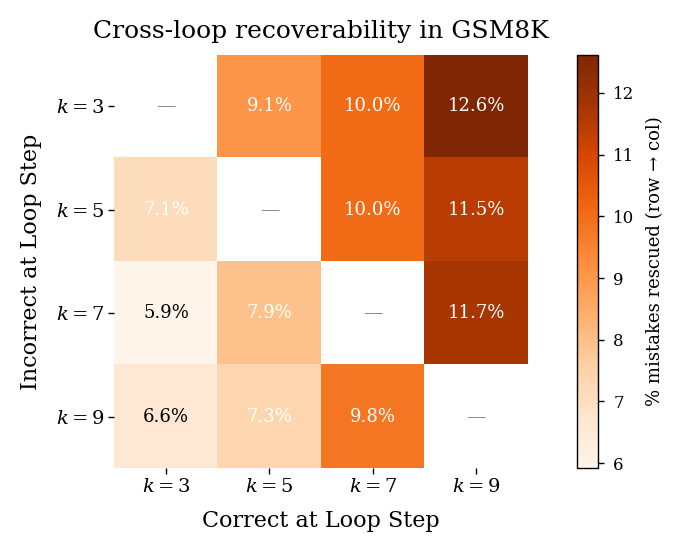


Absolute pairwise correction counts:
       $k=3$  $k=5$  $k=7$  $k=9$
$k=3$      0    104    115    145
$k=5$     80      0    113    129
$k=7$     65     87      0    129
$k=9$     71     79    105      0

As % of row-loop's mistakes:
       $k=3$  $k=5$  $k=7$  $k=9$
$k=3$    NaN   9.05  10.01  12.62
$k=5$   7.11    NaN  10.04  11.47
$k=7$   5.91   7.92    NaN  11.74
$k=9$   6.60   7.35   9.77    NaN


In [ ]:
# ---------------------------------------------------------------------------
# 2. Pairwise "correction" heatmap.
#    M[i, j] = # samples WRONG under L_i but CORRECT under L_j     (i = row, j = col)
#    Diagonal is set to NaN (a loop cannot rescue itself).
# ---------------------------------------------------------------------------
n = len(LOOP_KEYS)
M_count = np.zeros((n, n), dtype=int)
M_pct_of_wrong_i = np.full((n, n), np.nan)   # normalized by # wrongs in row i

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    n_wrong_i = int(wrong_mask[ki].sum())
    for j, kj in enumerate(LOOP_KEYS):
        if i == j:
            continue
        cnt = int((wrong_mask[ki] & right_mask[kj]).sum())
        M_count[i, j] = cnt
        if n_wrong_i:
            M_pct_of_wrong_i[i, j] = cnt / n_wrong_i * 100.0

# Double-column figure (~6.6in wide).
fig, axes = plt.subplots(1, 1, figsize=(6.6, 2.8))

def _heat(ax, mat, title, fmt, cmap, cbar_label):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(LOOP_KEYS)
    ax.set_yticks(range(n)); ax.set_yticklabels(LOOP_KEYS)
    ax.set_xlabel("Correct at Loop Step", labelpad=5)
    ax.set_ylabel("Incorrect at Loop Step", labelpad=5)
    ax.set_title(title, pad=3)
    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=7)
            else:
                v = mat[i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white" if v > np.nanmax(mat) * 0.55 else "black",
                        fontsize=6.5)
    ax.tick_params(length=2, pad=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=6.5)
    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.5)

# _heat(axes[0], M_count.astype(float), "Corrections (absolute count)",
#       "{:.0f}", "Blues", "# wrong in row, right in col")
_heat(axes, M_pct_of_wrong_i,
      "",
      "{:.1f}%", "Oranges", "% mistakes rescued (row → col)")

# fig.suptitle("Cross-loop recoverability in GSM8K", fontsize=9, x=1, y=0.99)

axes.set_title(f"Cross-loop recoverability in GSM8K", fontsize=9)
# fig.tight_layout(pad=0.3, w_pad=1.5)
fig.tight_layout()

fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.pdf", bbox_inches="tight")
# fig.savefig(PLOTS_DIR / "recoverability_pairwise_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAbsolute pairwise correction counts:")
print(pd.DataFrame(M_count, index=LOOP_KEYS, columns=LOOP_KEYS))
print("\nAs % of row-loop's mistakes:")
print(pd.DataFrame(M_pct_of_wrong_i, index=LOOP_KEYS, columns=LOOP_KEYS).round(2))

# Generated-token analysis across loops

How many tokens does each loop count generate on GSM8K, and how does the
distribution differ? Uses `metrics.num_tokens` (per response) and
`metrics.max_tokens_reached` (whether the response hit the decoding cap),
both already loaded into `df` as `toks_{L}` / `maxtok_{L}` in cell 5.

In [22]:
LOOP_COLORS = [plt.cm.viridis(v) for v in np.linspace(0.12, 0.80, len(LOOP_KEYS))]

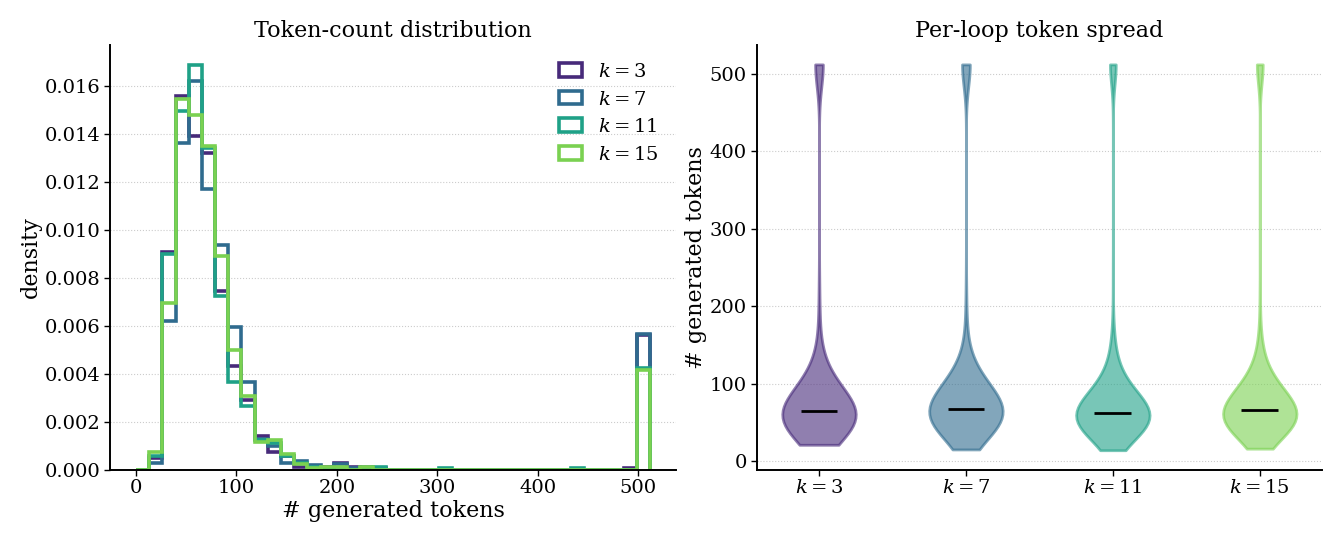

In [23]:
# ---------------------------------------------------------------------------
# 8. Generated-token distribution across loops.
#    (a) overlaid (density-normalised) step histograms of #tokens / response
#    (b) violin plot of per-loop token spread (median marked)
# ---------------------------------------------------------------------------
LOOP_COLORS = [plt.cm.viridis(v) for v in np.linspace(0.12, 0.80, len(LOOP_KEYS))]
tok_data = {k: df[f"toks_{k}"].values for k in LOOP_KEYS}

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.6))

MAXTOK = int(max(v.max() for v in tok_data.values()))
bins = np.linspace(0, MAXTOK, 40)
for k, c in zip(LOOP_KEYS, LOOP_COLORS):
    axes[0].hist(tok_data[k], bins=bins, density=True, histtype="step",
                 lw=1.3, color=c, label=k)
axes[0].set_xlabel("# generated tokens", labelpad=1)
axes[0].set_ylabel("density", labelpad=1)
axes[0].set_title("Token-count distribution", pad=3)
axes[0].legend(frameon=False, handlelength=1.2)
_emnlp_ax(axes[0])

parts = axes[1].violinplot([tok_data[k] for k in LOOP_KEYS], showmedians=True,
                           showextrema=False)
for pc, c in zip(parts["bodies"], LOOP_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.6); pc.set_edgecolor(c)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.0)
axes[1].set_xticks(range(1, len(LOOP_KEYS) + 1)); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("# generated tokens", labelpad=1)
axes[1].set_title("Per-loop token spread", pad=3)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_distribution.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

          mean  median     std  pct_maxtok
$k=3$    99.91    65.0  120.00        7.35
$k=7$   103.10    67.0  119.00        7.43
$k=11$   90.97    62.0  106.06        5.53
$k=15$   92.22    66.0  104.43        5.46


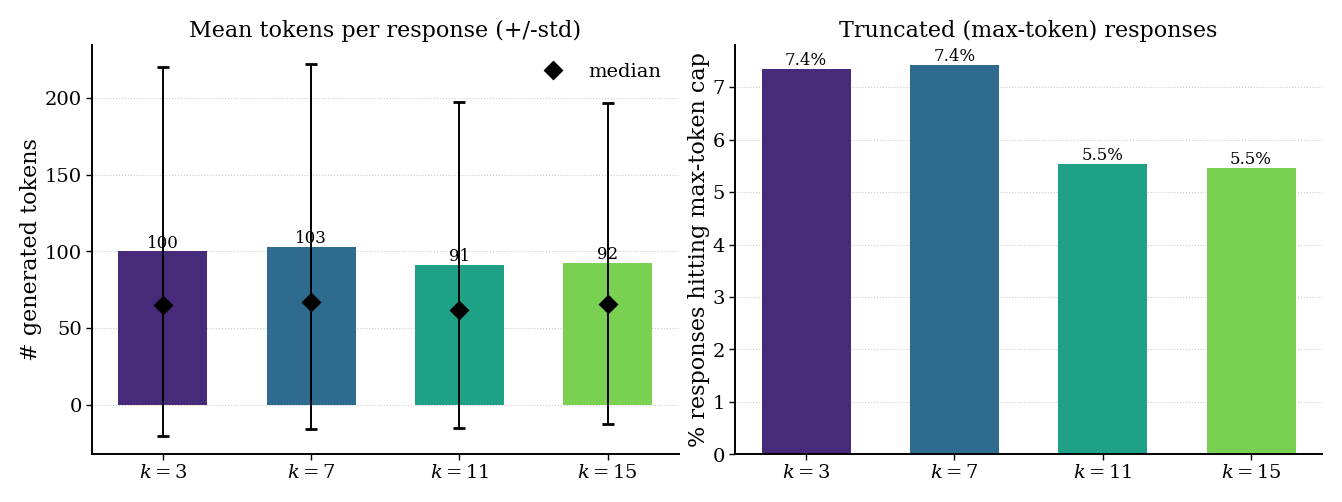

In [24]:
# ---------------------------------------------------------------------------
# 9. Number of generated tokens per loop: mean (+/-std), median, and the
#    fraction of responses that hit the max-token decoding cap (truncated).
# ---------------------------------------------------------------------------
tok_summary = pd.DataFrame({
    "mean":       [df[f"toks_{k}"].mean()      for k in LOOP_KEYS],
    "median":     [df[f"toks_{k}"].median()    for k in LOOP_KEYS],
    "std":        [df[f"toks_{k}"].std()       for k in LOOP_KEYS],
    "pct_maxtok": [df[f"maxtok_{k}"].mean()*100 for k in LOOP_KEYS],
}, index=LOOP_KEYS)
print(tok_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))
x = np.arange(len(LOOP_KEYS))

axes[0].bar(x, tok_summary["mean"], yerr=tok_summary["std"], width=0.6,
            color=LOOP_COLORS, zorder=2, capsize=2, error_kw=dict(lw=0.7))
axes[0].plot(x, tok_summary["median"], "D", ms=4, color="black", label="median", zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(LOOP_KEYS)
axes[0].set_ylabel("# generated tokens", labelpad=1)
axes[0].set_title("Mean tokens per response (+/-std)", pad=3)
axes[0].legend(frameon=False)
for i, v in enumerate(tok_summary["mean"]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[0])

axes[1].bar(x, tok_summary["pct_maxtok"], width=0.6, color=LOOP_COLORS, zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("% responses hitting max-token cap", labelpad=1)
axes[1].set_title("Truncated (max-token) responses", pad=3)
for i, v in enumerate(tok_summary["pct_maxtok"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_count_summary.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_count_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# Generated-token analysis — per-loop correct samples

Same two plots, but each loop's distribution is taken over the samples *that
loop itself* answered correctly (not necessarily the same samples across
loops, and not requiring agreement). This answers: "when loop L gets the
answer right, how many tokens does it spend?" Note each loop therefore has a
different sample size (its own accuracy count).

         mean  median    std  pct_maxtok    n
$k=3$   74.17    64.0  70.62        2.37  169
$k=7$   68.51    60.0  53.73        1.26  239
$k=11$  60.93    55.5  22.99        0.00  210
$k=15$  63.88    58.0  23.17        0.00  251


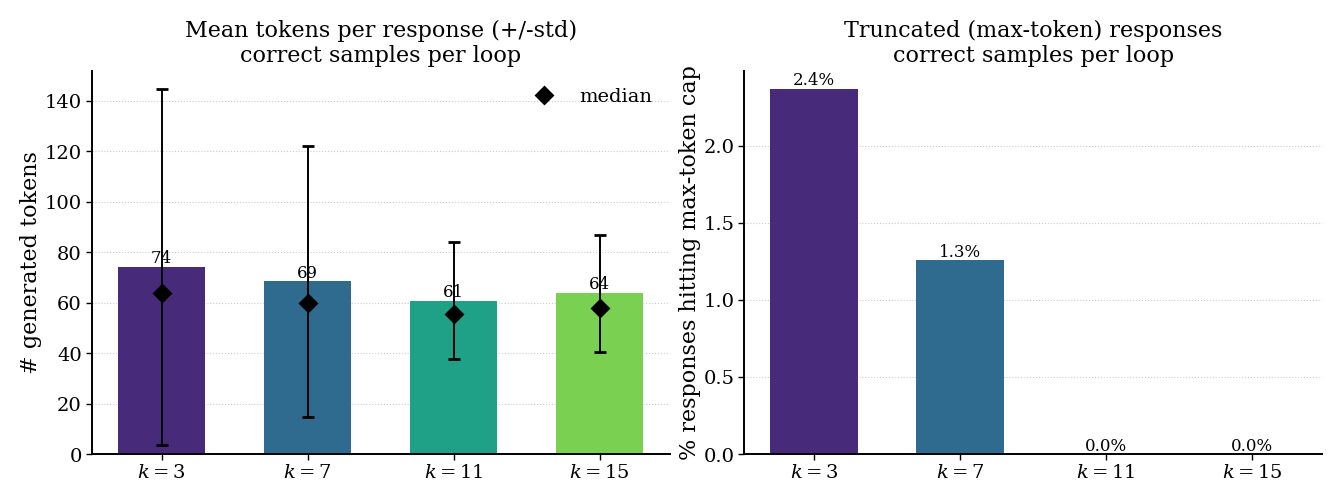

In [28]:
# ---------------------------------------------------------------------------
# 13. Number of generated tokens -- per-loop correct samples.
# ---------------------------------------------------------------------------
tok_summary = pd.DataFrame({
    "mean":       [tok_data[k].mean()               for k in LOOP_KEYS],
    "median":     [np.median(tok_data[k])           for k in LOOP_KEYS],
    "std":        [tok_data[k].std(ddof=1)          for k in LOOP_KEYS],
    "pct_maxtok": [df.loc[df[f"em_{k}"] == 1, f"maxtok_{k}"].mean()*100 for k in LOOP_KEYS],
    "n":          [ns[k]                            for k in LOOP_KEYS],
}, index=LOOP_KEYS)
print(tok_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.4))
x = np.arange(len(LOOP_KEYS))

axes[0].bar(x, tok_summary["mean"], yerr=tok_summary["std"], width=0.6,
            color=LOOP_COLORS, zorder=2, capsize=2, error_kw=dict(lw=0.7))
axes[0].plot(x, tok_summary["median"], "D", ms=4, color="black", label="median", zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(LOOP_KEYS)
axes[0].set_ylabel("# generated tokens", labelpad=1)
axes[0].set_title(f"Mean tokens per response (+/-std)\n{SUFFIX}", pad=3)
axes[0].legend(frameon=False)
for i, v in enumerate(tok_summary["mean"]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[0])

axes[1].bar(x, tok_summary["pct_maxtok"], width=0.6, color=LOOP_COLORS, zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(LOOP_KEYS)
axes[1].set_ylabel("% responses hitting max-token cap", labelpad=1)
axes[1].set_title(f"Truncated (max-token) responses\n{SUFFIX}", pad=3)
for i, v in enumerate(tok_summary["pct_maxtok"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=6)
_emnlp_ax(axes[1])

fig.tight_layout(pad=0.4)
fig.savefig(PLOTS_DIR / "token_count_summary_correct_per_loop.pdf", bbox_inches="tight")
fig.savefig(PLOTS_DIR / "token_count_summary_correct_per_loop.png", dpi=300, bbox_inches="tight")
plt.show()

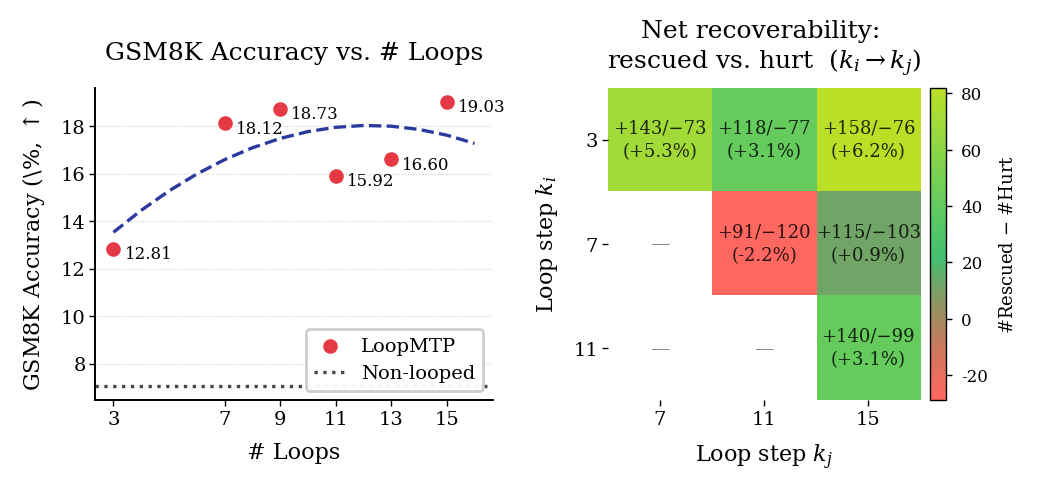


Total samples (denominator for %): 1319

Rescued counts (wrong@row -> right@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0    143     118     158
$k=7$       0      0      91     115
$k=11$      0      0       0     140
$k=15$      0      0       0       0

Hurt counts (right@row -> wrong@col):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$       0     73      77      76
$k=7$       0      0     120     103
$k=11$      0      0       0      99
$k=15$      0      0       0       0

Net (rescued - hurt):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   70.0    41.0    82.0
$k=7$     NaN    NaN   -29.0    12.0
$k=11$    NaN    NaN     NaN    41.0
$k=15$    NaN    NaN     NaN     NaN

Rescued % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN  10.84    8.95   11.98
$k=7$     NaN    NaN    6.90    8.72
$k=11$    NaN    NaN     NaN   10.61
$k=15$    NaN    NaN     NaN     NaN

Hurt % (of all samples):
        $k=3$  $k=7$  $k=11$  $k=15$
$k=3$     NaN   5.53   

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1.2,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ─────────────────────────────────────────────────────────────────────────────
# Two-panel figure: (a) accuracy extrapolation   (b) perplexity @ 5B tokens
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax) = plt.subplots(1, 2, figsize=(5, 2.2))

# ── Subplot (a): GSM8K accuracy vs. # loops ──────────────────────────────────
loops_data   = np.array([3, 7, 9, 11, 13, 15])
mtp_acc_data = np.array([12.813, 18.12, 18.726, 15.921, 16.603, 19.03])

coeffs = np.polyfit(loops_data, mtp_acc_data, 2)  # slope, intercept
poly   = np.poly1d(coeffs)

loops_extrap   = np.arange(3, 17)
mtp_acc_extrap = poly(loops_extrap)

ax1.scatter(loops_data, mtp_acc_data, color="#e63946", s=18, zorder=5, label="LoopMTP")
for l, a in zip(loops_data, mtp_acc_data):
    ax1.annotate(f"{a:.2f}", (l + 0.1, a - 0.755), textcoords="offset points", xytext=(3, 3), fontsize=6,
    )

non_looped_baseline = 7.05
ax1.axhline(non_looped_baseline, color="#48464D", linestyle=":", linewidth=1.2, label="Non-looped")

ax1.plot(loops_extrap, mtp_acc_extrap, "--", color="#2b3a9e", linewidth=1.2,
)
        #  label=f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$")

ax1.set_xlabel("# Loops", labelpad=5)
ax1.set_ylabel("GSM8K Accuracy (\\%, $\\uparrow$)", labelpad=5)
# ax1.set_xticks(loops_extrap[::2])
ax1.set_xticks(loops_data)
ax1.tick_params(length=2, pad=1.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
ax1.set_axisbelow(True)
# ax1.set_title("(a) Accuracy extrapolation", pad=3)
ax1.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", handlelength=1.6, loc="lower right")

ax1.set_title("GSM8K Accuracy vs. # Loops", fontsize=9, pad=10)

# fig.tight_layout()
# Path("./plots").mkdir(exist_ok=True)
# fig.savefig("./plots/math_expert_extrapolation_wo_ppl.pdf", bbox_inches="tight")





from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------------------------------------------------------------------------
# 3. Pairwise NET recoverability heatmap (rescued vs hurt).
# ---------------------------------------------------------------------------

n = len(LOOP_KEYS)
N = len(df)

M_rescued = np.zeros((n, n), dtype=int)
M_hurt    = np.zeros((n, n), dtype=int)
M_net     = np.full((n, n), np.nan)

M_rescued_pct = np.full((n, n), np.nan)
M_hurt_pct    = np.full((n, n), np.nan)

wrong_mask = {k: (df[f"em_{k}"] == 0) for k in LOOP_KEYS}
right_mask = {k: (df[f"em_{k}"] == 1) for k in LOOP_KEYS}

for i, ki in enumerate(LOOP_KEYS):
    for j, kj in enumerate(LOOP_KEYS):
        if j <= i:
            continue
        r = int((wrong_mask[ki] & right_mask[kj]).sum())
        h = int((right_mask[ki] & wrong_mask[kj]).sum())
        M_rescued[i, j] = r
        M_hurt[i, j]    = h
        M_net[i, j]     = r - h
        M_rescued_pct[i, j] = r / N * 100.0
        M_hurt_pct[i, j]    = h / N * 100.0


# ---------------------------------------------------------------------------
# Drop the always-empty first column (j=0) and last row (i=n-1).
# ---------------------------------------------------------------------------
net_view = M_net[:-1, 1:]
x_labels = LOOP_KEYS[1:]
x_labels = [x.replace("$", "").replace("k=" , "") for x in x_labels]
y_labels = LOOP_KEYS[:-1]
y_labels = [y.replace("$", "").replace("k=" , "") for y in y_labels]

vmin = float(np.nanmin(net_view))
vmax = float(np.nanmax(net_view))
vmin = min(vmin, -1e-9)
vmax = max(vmax,  1e-9)

# ---------------------------------------------------------------------------
# Linear normalization (NOT TwoSlopeNorm). Zero sits at its true proportional
# position on the bar -> short red section, long green section.
# ---------------------------------------------------------------------------
norm = Normalize(vmin=vmin, vmax=vmax)

# Build the colormap so its red->green transition aligns with 0 in data space.
zero_frac = (0.0 - vmin) / (vmax - vmin)   # fraction of bar below 0
n_total = 256
n_neg = max(1, int(round(zero_frac * n_total)))
n_pos = n_total - n_neg

pos_colors = plt.cm.viridis(np.linspace(0.7, 0.9, 80))
neg_anchor = pos_colors[0]
neg_colors = LinearSegmentedColormap.from_list(
    "neg", ["#ff0d009f", neg_anchor]
)(np.linspace(0, 1, n_neg))
cmap = LinearSegmentedColormap.from_list(
    "viridis_div_red", np.vstack([neg_colors, pos_colors])
)

# ---------------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------------
# fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.5))
im = ax.imshow(net_view, cmap=cmap, norm=norm)

rows, cols = net_view.shape
ax.set_xticks(range(cols)); ax.set_xticklabels(x_labels)
ax.set_yticks(range(rows)); ax.set_yticklabels(y_labels)
ax.set_xlabel(r"Loop step $k_j$", labelpad=5)
ax.set_ylabel(r"Loop step $k_i$", labelpad=5)
ax.set_title("Net recoverability: \nrescued vs. hurt  ($k_i \\to k_j$)",
             fontsize=9, pad=7)

for i in range(rows):
    for j in range(cols):
        orig_i = i
        orig_j = j + 1
        if orig_j <= orig_i:
            ax.text(j, i, "—", ha="center", va="center",
                    color="gray", fontsize=7)
            continue
        net = M_net[orig_i, orig_j]
        if np.isnan(net):
            continue
        txt_color = "#000000D2"
        net_pct = net / N * 100.0
        ax.text(
            j, i,
            f"+{M_rescued[orig_i, orig_j]}/−{M_hurt[orig_i, orig_j]}\n"
            f"({net_pct:+.1f}%)",
            ha="center", va="center", color=txt_color, fontsize=6.5,
            linespacing=1.4,
        )

ax.tick_params(length=2, pad=1.5)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------------------------------------------------------------
# Colorbar: evenly spaced ticks every `tick_step` units across the whole bar.
# Zero is naturally included; spacing is uniform in data units.
# ---------------------------------------------------------------------------
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.025)
cb.set_label("#Rescued $-$ #Hurt", fontsize=6.5)

tick_step = 20   # change to 10 / 25 to taste
cb.ax.yaxis.set_major_locator(MultipleLocator(tick_step))
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}"))
cb.ax.tick_params(labelsize=6, length=2)
cb.outline.set_linewidth(0.5)

# set the wite space left to right to the smallest possible
fig.tight_layout(pad=0.0, w_pad=-1.5)

fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap_GSM_accuracy.pdf",
            bbox_inches="tight")
fig.savefig(PLOTS_DIR / "recoverability_net_pairwise_heatmap_small.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------------
# Print tables
# ---------------------------------------------------------------------------
idx, col = LOOP_KEYS, LOOP_KEYS
print(f"\nTotal samples (denominator for %): {N}")
print("\nRescued counts (wrong@row -> right@col):")
print(pd.DataFrame(M_rescued, index=idx, columns=col))
print("\nHurt counts (right@row -> wrong@col):")
print(pd.DataFrame(M_hurt, index=idx, columns=col))
print("\nNet (rescued - hurt):")
print(pd.DataFrame(M_net, index=idx, columns=col))
print("\nRescued % (of all samples):")
print(pd.DataFrame(M_rescued_pct, index=idx, columns=col).round(2))
print("\nHurt % (of all samples):")
print(pd.DataFrame(M_hurt_pct, index=idx, columns=col).round(2))
